# TBD title

todo intro

# PCA From Scratch

In [36]:
# Part 0 - Imports
import numpy as np
import matplotlib.pyplot as plt

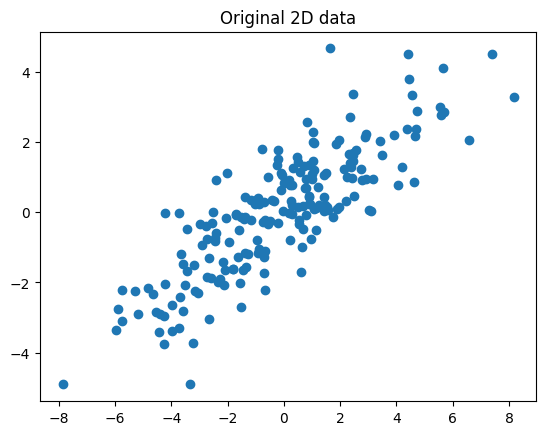

In [37]:
# Part 1 - Create a 2D dataset where PCA is obvious
np.random.seed(42)

# create x as 200 samples from N(0, 3)
x = np.random.normal(0, 3, 200)

# create y so that it is correlated with x (hint: 0.5 * x + noise)
y = 0.5 * x + np.random.normal(0, 1, 200)

# stack x and y into matrix X of shape (200, 2)
X = np.column_stack((x, y))

plt.scatter(X[:, 0], X[:, 1])
plt.title("Original 2D data")
plt.show()

In [38]:
# Part 2 -  Center the data
# compute mean of X (per column)
X_mean = np.mean(X, axis=0)

# center the data
X_centered = X - X_mean

print(X_mean)

[-0.1223129   0.02471174]


In [39]:
# Part 3 -  compute covariance matrix of X_centered
cov_matrix = np.cov(X_centered, rowvar=False)

print(cov_matrix)

[[7.80091461 4.16274942]
 [4.16274942 3.18669729]]


In [40]:
# Part 4 -  Eigen decomposition
# eigenvalues and eigenvectors of covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues:
 [10.25313711  0.73447479]
Eigenvectors:
 [[ 0.86161326 -0.50756536]
 [ 0.50756536  0.86161326]]


In [41]:
# Part 5 - Sort components by importance
# sort indices of eigenvalues in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]

# reorder eigenvalues and eigenvectors
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

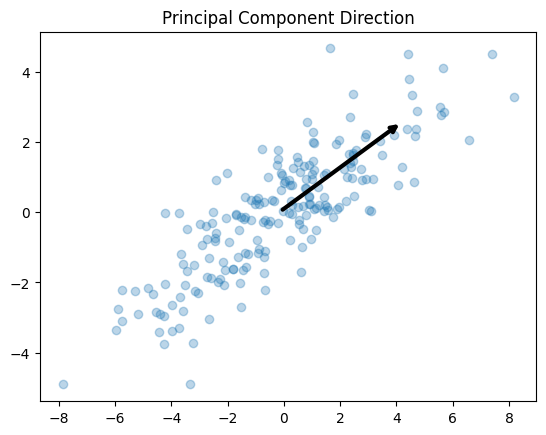

In [43]:
# Part 6 - Visualize the principal direction
plt.scatter(X[:,0], X[:,1], alpha=0.3)

# take the first eigenvector
v = eigenvectors[:,0]

# draw the vector starting from mean
plt.annotate(
    '',
    xy=(X_mean[0] + 5*v[0], X_mean[1] + 5*v[1]),
    xytext=(X_mean[0], X_mean[1]),
    arrowprops=dict(arrowstyle='->', linewidth=3)
)

plt.title("Principal Component Direction")
plt.show()

In [44]:
# Part 7 - Project data to 1D (2D → 1D)
# select first eigenvector as component matrix (shape (2,1))
component = eigenvectors[:, :1]

# project centered data onto this component
X_reduced = np.dot(X_centered, component)

print(X_reduced.shape)

(200, 1)


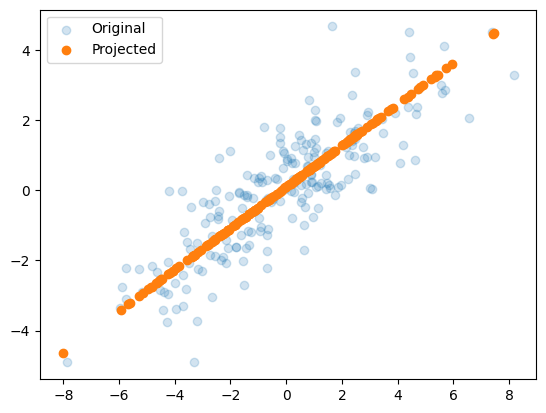

In [45]:
# Part 8 - Reconstruct back to 2D for visualization
#  reconstruct points back to 2D
X_projected = X_reduced @ component.T + X_mean

plt.scatter(X[:,0], X[:,1], alpha=0.2, label="Original")
plt.scatter(X_projected[:,0], X_projected[:,1], label="Projected")
plt.legend()
plt.show()

## PCA function

In [46]:
# Part 9 - Wrap everything into a PCA function
def pca_from_scratch(X, n_components):
    # Center
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    # Covariance
    cov = np.cov(X_centered, rowvar=False)

    # Eigen
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Select components
    components = eigenvectors[:, :n_components]

    # Project
    X_reduced = np.dot(X_centered, components)

    return X_reduced, components, eigenvalues

## Iris - smoke test

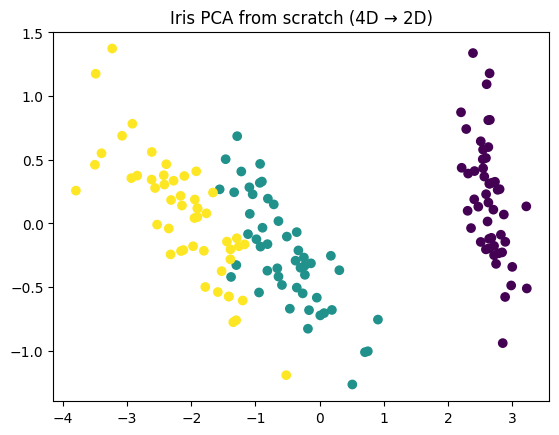

In [50]:
# Part 10 - Apply PCA to a real dataset (4D → 2D)
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_iris_reduced, components_iris, eigenvalues_iris = pca_from_scratch(X_iris, 2)

plt.scatter(X_iris_reduced[:,0], X_iris_reduced[:,1], c=y_iris)
plt.title("Iris PCA from scratch (4D → 2D)")
plt.show()